In [1410]:
import pandas as pd

In [1411]:
#upload of CPI (MonthOverMonth)
CPI_MoM = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\Indexs\US indexs\MoM Indexs\CPIAUCSL_PCH.csv")
CPI_MoM.isnull().sum()
CPI_MoM['CPIAUCSL_PCH'] = CPI_MoM['CPIAUCSL_PCH'].interpolate(method='linear')
CPI_MoM.rename(columns={"CPIAUCSL_PCH":"CPI_MoM"},inplace=True)
CPI_MoM

,observation_date,CPI_MoM
0,2015-01-01,-0.63703
1,2015-02-01,0.25346
2,2015-03-01,0.26940
3,2015-04-01,0.10425
4,2015-05-01,0.32977
...,...,...
127,2025-08-01,0.34826
128,2025-09-01,0.29509
129,2025-10-01,0.29599
130,2025-11-01,0.29689


In [1412]:
#convert time to YEar - Month format 
CPI_MoM.info()
CPI_MoM["observation_date"] = pd.to_datetime(CPI_MoM["observation_date"])
CPI_MoM["observation_date"] = CPI_MoM["observation_date"].dt.strftime('%Y-%m')
CPI_MoM = CPI_MoM.iloc[2:]
CPI_MoM


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  132 non-null    object 
 1   CPI_MoM           132 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.2+ KB


,observation_date,CPI_MoM
2,2015-03,0.26940
3,2015-04,0.10425
4,2015-05,0.32977
5,2015-06,0.27679
6,2015-07,0.15863
...,...,...
127,2025-08,0.34826
128,2025-09,0.29509
129,2025-10,0.29599
130,2025-11,0.29689


In [1413]:
#upload of Duties (overall Value)
duties = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\MTS_RcptSrcOutlyFcn_20150331_20251231.csv")
duties = duties[["Record Date","Current Month Receipt or Outlay Amount"]]
duties.rename(columns={"Current Month Receipt or Outlay Amount":"Total_Duties",
                       "Record Date":"observation_date"},inplace=True)
duties["Total_Duties"] = duties["Total_Duties"]/1000000
duties

,observation_date,Total_Duties
0,2025-12-31,27892.382035
1,2025-11-30,30755.952020
2,2025-10-31,31353.501081
3,2025-09-30,29674.953322
4,2025-08-31,29502.942750
...,...,...
125,2015-07-31,3601.679120
126,2015-06-30,2941.109731
127,2015-05-31,2547.830672
128,2015-04-30,3429.774742


In [1414]:
#convert time to Year - Month format 
duties.info()
duties["observation_date"] = pd.to_datetime(duties["observation_date"])
duties["observation_date"] = duties["observation_date"].dt.strftime('%Y-%m')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  130 non-null    object 
 1   Total_Duties      130 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.2+ KB


In [1415]:
#convert duties to MoM % change
duties.sort_values(by="observation_date",inplace=True)
duties["Duties_MoM_0"] = duties["Total_Duties"].pct_change(periods=1) * 100
duties

,observation_date,Total_Duties,Duties_MoM_0
129,2015-03,2626.601268,NaN
128,2015-04,3429.774742,30.578432
127,2015-05,2547.830672,-25.714344
126,2015-06,2941.109731,15.435840
125,2015-07,3601.679120,22.459869
...,...,...,...
4,2025-08,29502.942750,6.624088
3,2025-09,29674.953322,0.583029
2,2025-10,31353.501081,5.656446
1,2025-11,30755.952020,-1.905845


In [1416]:
combined_table = pd.merge(duties,CPI_MoM,how="left",on="observation_date")
combined_table = combined_table.set_index('observation_date')
combined_table

,Total_Duties,Duties_MoM_0,CPI_MoM
observation_date,,,
2015-03,2626.601268,NaN,0.26940
2015-04,3429.774742,30.578432,0.10425
2015-05,2547.830672,-25.714344,0.32977
2015-06,2941.109731,15.435840,0.27679
2015-07,3601.679120,22.459869,0.15863
...,...,...,...
2025-08,29502.942750,6.624088,0.34826
2025-09,29674.953322,0.583029,0.29509
2025-10,31353.501081,5.656446,0.29599


In [1417]:
#creation of new series of Duties with month delays (1-12 months)

for i in range(1, 13):
    combined_table[f"Duties_MoM_{i}"] = combined_table["Duties_MoM_0"].shift(i)
combined_table.head(20)
    

,Total_Duties,Duties_MoM_0,CPI_MoM,Duties_MoM_1,Duties_MoM_2,Duties_MoM_3,Duties_MoM_4,Duties_MoM_5,Duties_MoM_6,Duties_MoM_7,Duties_MoM_8,Duties_MoM_9,Duties_MoM_10,Duties_MoM_11,Duties_MoM_12
observation_date,,,,,,,,,,,,,,,
2015-03,2626.601268,NaN,0.26940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,3429.774742,30.578432,0.10425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05,2547.830672,-25.714344,0.32977,30.578432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06,2941.109731,15.435840,0.27679,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07,3601.679120,22.459869,0.15863,15.435840,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-08,1907.511206,-47.038280,-0.00042,22.459869,15.435840,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-09,3197.759599,67.640410,-0.22476,-47.038280,22.459869,15.435840,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-10,3435.496536,7.434484,0.09895,67.640410,-47.038280,22.459869,15.435840,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN,NaN
2015-11,2886.781802,-15.971919,0.11946,7.434484,67.640410,-47.038280,22.459869,15.435840,-25.714344,30.578432,NaN,NaN,NaN,NaN,NaN


In [1418]:
#Find the best series for duties and see if those lags are statistically significant:
#H0: Duties (multiple lags) inputs dont help predict CPI;
#H1: Duties (multiple lags) inputs help predict CPI;
duties_candidates = combined_table.filter(like="Duties_MoM").dropna()

results = []

for col in duties_candidates.columns:
    
    df = combined_table[[col, "CPI_MoM"]].dropna()
    
    r, pvalue = pearsonr(df[col], df["CPI_MoM"])
    
    results.append({
        "Candidate": col,
        "Correlation": r,
        "p_value": pvalue,
        "N": len(df)
    })

results = pd.DataFrame(results).sort_values("Correlation", ascending=False)
results

,Candidate,Correlation,p_value,N
6,Duties_MoM_6,0.073999,0.415976,123
11,Duties_MoM_11,0.044483,0.632432,118
1,Duties_MoM_1,0.036727,0.680642,128
12,Duties_MoM_12,0.036178,0.698568,117
2,Duties_MoM_2,0.021462,0.810714,127
4,Duties_MoM_4,0.009194,0.918947,125
7,Duties_MoM_7,0.000126,0.998900,122
5,Duties_MoM_5,-0.006972,0.938741,124
9,Duties_MoM_9,-0.009863,0.914854,120
0,Duties_MoM_0,-0.023791,0.788995,129


In [1419]:
#All lags fail to reject H0. For this reason, I'll not consider "Duties_YoY_6" as feature for my model!

In [1420]:

#Let's move on to check Import Price Index and apply the same logic:
ImportPrice = pd.read_excel(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\Indexs\US indexs\MoM Indexs\IREXFDFLS_PCH.xlsx",sheet_name="Monthly")
ImportPrice["observation_date"] = ImportPrice["observation_date"].dt.strftime('%Y-%m')
ImportPrice.rename(columns={"IREXFDFLS_PCH":"ImportPrice_MoM_0"},inplace=True)
ImportPrice['ImportPrice_MoM_0'] = ImportPrice['ImportPrice_MoM_0'].interpolate(method='linear')
ImportPrice = ImportPrice.set_index('observation_date')
ImportPrice = ImportPrice.iloc[1:]
ImportPrice

,ImportPrice_MoM_0
observation_date,
2015-03,-0.396830
2015-04,-0.298800
2015-05,0.000000
2015-06,-0.199800
2015-07,-0.200200
...,...
2025-08,0.182480
2025-09,0.000000
2025-10,0.090663


In [1421]:
#Lets create lag series for ImportPrice:
IP_CPI = pd.concat([ImportPrice["ImportPrice_MoM_0"],combined_table["CPI_MoM"]],axis=1,join="inner")

for i in range(1, 13):
    IP_CPI[f"ImportPrice_MoM_{i}"] = IP_CPI["ImportPrice_MoM_0"].shift(i)
IP_CPI


,ImportPrice_MoM_0,CPI_MoM,ImportPrice_MoM_1,ImportPrice_MoM_2,ImportPrice_MoM_3,ImportPrice_MoM_4,ImportPrice_MoM_5,ImportPrice_MoM_6,ImportPrice_MoM_7,ImportPrice_MoM_8,ImportPrice_MoM_9,ImportPrice_MoM_10,ImportPrice_MoM_11,ImportPrice_MoM_12
observation_date,,,,,,,,,,,,,,
2015-03,-0.396830,0.26940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,-0.298800,0.10425,-0.396830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05,0.000000,0.32977,-0.298800,-0.396830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06,-0.199800,0.27679,0.000000,-0.298800,-0.39683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07,-0.200200,0.15863,-0.199800,0.000000,-0.29880,-0.39683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08,0.182480,0.34826,0.091320,-0.182320,0.00000,0.36597,-0.09141,0.09149,0.00000,-0.18265,-0.09124,0.27447,0.27523,0.00000
2025-09,0.000000,0.29509,0.182480,0.091320,-0.18232,0.00000,0.36597,-0.09141,0.09149,0.00000,-0.18265,-0.09124,0.27447,0.27523
2025-10,0.090663,0.29599,0.000000,0.182480,0.09132,-0.18232,0.00000,0.36597,-0.09141,0.09149,0.00000,-0.18265,-0.09124,0.27447


In [1422]:
#Find the best series for import price and see if any lag is actually statistically significant:
#H0: Import Price (any lag) inputs dont help predict CPI;
#H1: Import Price (any lag) inputs help predict CPI;
from scipy.stats import pearsonr

IP_candidates = IP_CPI.filter(like="ImportPrice_MoM").dropna()

results = []

for col in IP_candidates.columns:
    
    df = IP_CPI[[col, "CPI_MoM"]].dropna()
    
    r, pvalue = pearsonr(df[col], df["CPI_MoM"])
    
    results.append({
        "Candidate": col,
        "Correlation": r,
        "p_value": pvalue,
        "N": len(df)
    })

results = pd.DataFrame(results).sort_values("Correlation", ascending=False)
results

,Candidate,Correlation,p_value,N
0,ImportPrice_MoM_0,0.405391,0.000002,130
1,ImportPrice_MoM_1,0.379408,0.000009,129
5,ImportPrice_MoM_5,0.357986,0.000042,125
2,ImportPrice_MoM_2,0.344671,0.000068,128
10,ImportPrice_MoM_10,0.340076,0.000145,120
3,ImportPrice_MoM_3,0.338508,0.000099,127
4,ImportPrice_MoM_4,0.332173,0.000145,126
6,ImportPrice_MoM_6,0.324166,0.000240,124
12,ImportPrice_MoM_12,0.320055,0.000411,118
11,ImportPrice_MoM_11,0.310955,0.000577,119


In [1423]:
#Means that I can reject H0 for all lags. For this reason, at this point, I could consider all these lags into features. However, considering the number of records and correlations, I'll only use 0,1,5,2,3,4

In [1424]:
#Let's move on to check Producer Price Index and apply the same logic:
ProducerPrice = pd.read_excel(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\Indexs\US indexs\MoM Indexs\PCUOMFGOMFG_PCH.xlsx",sheet_name="Monthly")
ProducerPrice["observation_date"] = ProducerPrice["observation_date"].dt.strftime('%Y-%m')
ProducerPrice.rename(columns={"PCUOMFGOMFG_PCH":"ProducerPrice_MoM_0"},inplace=True)
ProducerPrice["ProducerPrice_MoM_0"] = ProducerPrice["ProducerPrice_MoM_0"].interpolate(method='linear')
ProducerPrice = ProducerPrice.set_index('observation_date')
ProducerPrice = ProducerPrice.iloc[1:]

In [1425]:
#Lets create lag series for ProducerPrice:
PP_CPI = pd.concat([ProducerPrice["ProducerPrice_MoM_0"],combined_table["CPI_MoM"]],axis=1,join="inner")
for i in range(1, 13):
    PP_CPI[f"ProducerPrice_MoM_{i}"] = PP_CPI["ProducerPrice_MoM_0"].shift(i)
PP_CPI

,ProducerPrice_MoM_0,CPI_MoM,ProducerPrice_MoM_1,ProducerPrice_MoM_2,ProducerPrice_MoM_3,ProducerPrice_MoM_4,ProducerPrice_MoM_5,ProducerPrice_MoM_6,ProducerPrice_MoM_7,ProducerPrice_MoM_8,ProducerPrice_MoM_9,ProducerPrice_MoM_10,ProducerPrice_MoM_11,ProducerPrice_MoM_12
observation_date,,,,,,,,,,,,,,
2015-03,0.43150,0.26940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,-0.26853,0.10425,0.43150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05,1.34626,0.32977,-0.26853,0.43150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06,0.37194,0.27679,1.34626,-0.26853,0.43150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07,-0.21175,0.15863,0.37194,1.34626,-0.26853,0.43150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08,0.01932,0.34826,0.64679,0.26298,0.35494,0.29512,-0.23251,0.66275,1.04802,-0.22422,-0.23461,0.35601,-1.13538,-0.27177
2025-09,0.36658,0.29509,0.01932,0.64679,0.26298,0.35494,0.29512,-0.23251,0.66275,1.04802,-0.22422,-0.23461,0.35601,-1.13538
2025-10,-0.47875,0.29599,0.36658,0.01932,0.64679,0.26298,0.35494,0.29512,-0.23251,0.66275,1.04802,-0.22422,-0.23461,0.35601


In [1426]:
#Find the best series for PP and see if any lag is statistically significant:
#H0: Producer Price (any lag) inputs dont help predict CPI;
#H1: Producer Price (any lag) inputs help predict CPI;

PP_candidates = PP_CPI.filter(like="ProducerPrice_MoM").dropna()

results = []

for col in PP_candidates.columns:
    
    df = PP_CPI[[col, "CPI_MoM"]].dropna()
    
    r, pvalue = pearsonr(df[col], df["CPI_MoM"])
    
    results.append({
        "Candidate": col,
        "Correlation": r,
        "p_value": pvalue,
        "N": len(df)
    })

results = pd.DataFrame(results).sort_values("Correlation", ascending=False)
results

,Candidate,Correlation,p_value,N
0,ProducerPrice_MoM_0,0.737850,1.332652e-23,130
1,ProducerPrice_MoM_1,0.470857,1.789694e-08,129
7,ProducerPrice_MoM_7,0.295919,8.901063e-04,123
8,ProducerPrice_MoM_8,0.265007,3.178815e-03,122
5,ProducerPrice_MoM_5,0.236054,8.044138e-03,125
10,ProducerPrice_MoM_10,0.228614,1.202255e-02,120
2,ProducerPrice_MoM_2,0.200206,2.346107e-02,128
4,ProducerPrice_MoM_4,0.184262,3.888095e-02,126
11,ProducerPrice_MoM_11,0.181451,4.827608e-02,119
3,ProducerPrice_MoM_3,0.168596,5.812206e-02,127


In [1427]:
###Multiple lags have p-value under 0.05. It means that I CAN reject H0. Therefore, I'll can use lags: 0,1,7,8,5,10,2,4 and 11. Due to number of records and correlations, I'll use only: 0,1,7,5

In [1428]:
#Let's move on to check Import Balance and apply the same logic:
trade2015 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2015.csv")
trade2016 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2016.csv")
trade2017 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2017.csv")
trade2018 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2018.csv")
trade2019 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2019.csv")
trade2020 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2020.csv")
trade2021 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2021.csv")
trade2022 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2022.csv")
trade2023 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2023.csv")
trade2024 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2024.csv")
trade2025 = pd.read_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Original Datasets\ML model\TradeData_2025.csv")
trade = pd.concat([trade2015,trade2016,trade2017,trade2018,trade2019,trade2020,trade2021,trade2022,trade2023,trade2024,trade2025])
trade = trade[["refMonth","flowCode","fobvalue"]]

In [1429]:
balance = trade.pivot_table(index="refMonth", columns="flowCode", values="fobvalue",aggfunc="sum").reset_index()
balance = balance.iloc[2:]
balance["Balance"] = balance["Export"] - balance["Import"]
balance.rename(columns={"refMonth":"observation_date"},inplace=True)

In [1430]:
balance["observation_date"] = pd.to_datetime(balance["observation_date"].astype(str), format='%Y%m')
balance["observation_date"] = balance["observation_date"].dt.strftime('%Y-%m')

In [1431]:
balance["Balance_MoM_0"] = balance["Balance"].pct_change(periods=1) * 100
balance = balance.set_index('observation_date')
balance

flowCode,Export,Import,Balance,Balance_MoM_0
observation_date,,,,
2015-03,133281207416,203662851812,-70381644396,NaN
2015-04,128247315144,194533558906,-66286243762,-5.818848
2015-05,128142016091,191492538570,-63350522479,-4.428854
2015-06,130946483350,201743707769,-70797224419,11.754760
2015-07,124094043067,198187451473,-74093408406,4.655810
...,...,...,...,...
2025-06,179795625974,272596273670,-92800647696,-7.898069
2025-07,175018015665,300413093156,-125395077491,35.123063
2025-08,179619870132,270273898933,-90654028801,-27.705273


In [1432]:
#Lets create lag series for balance:
BAL = pd.concat([balance["Balance_MoM_0"],combined_table["CPI_MoM"]],axis=1)
for i in range(1, 13):
    BAL[f"Balance_MoM_{i}"] = BAL["Balance_MoM_0"].shift(i)
BAL

,Balance_MoM_0,CPI_MoM,Balance_MoM_1,Balance_MoM_2,Balance_MoM_3,Balance_MoM_4,Balance_MoM_5,Balance_MoM_6,Balance_MoM_7,Balance_MoM_8,Balance_MoM_9,Balance_MoM_10,Balance_MoM_11,Balance_MoM_12
observation_date,,,,,,,,,,,,,,
2015-03,NaN,0.26940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-04,-5.818848,0.10425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-05,-4.428854,0.32977,-5.818848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06,11.754760,0.27679,-4.428854,-5.818848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07,4.655810,0.15863,11.754760,-4.428854,-5.818848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08,-27.705273,0.34826,35.123063,-7.898069,6.028554,-40.450917,24.993723,-20.815727,27.687628,17.631360,-10.456846,-2.411735,16.823755,-17.312833
2025-09,7.468790,0.29509,-27.705273,35.123063,-7.898069,6.028554,-40.450917,24.993723,-20.815727,27.687628,17.631360,-10.456846,-2.411735,16.823755
2025-10,-19.289433,0.29599,7.468790,-27.705273,35.123063,-7.898069,6.028554,-40.450917,24.993723,-20.815727,27.687628,17.631360,-10.456846,-2.411735


In [1433]:
#Find the best series for BAL and see if any lag is actually statistically significant:
#H0: Commercial Balance (any lag) inputs dont help predict CPI;
#H1: Commercial Balance (any lag) inputs help predict CPI;
BAL_candidates = BAL.filter(like="Balance_MoM").dropna()

results = []

for col in BAL_candidates.columns:
    
    df = BAL[[col, "CPI_MoM"]].dropna()
    
    r, pvalue = pearsonr(df[col], df["CPI_MoM"])
    
    results.append({
        "Candidate": col,
        "Correlation": r,
        "p_value": pvalue,
        "N": len(df)
    })

results = pd.DataFrame(results).sort_values("Correlation", ascending=False)
results

,Candidate,Correlation,p_value,N
3,Balance_MoM_3,0.116428,0.194184,126
6,Balance_MoM_6,0.055182,0.544376,123
7,Balance_MoM_7,0.047737,0.601568,122
9,Balance_MoM_9,0.035016,0.704179,120
0,Balance_MoM_0,0.032739,0.714817,127
5,Balance_MoM_5,0.025494,0.778661,124
8,Balance_MoM_8,0.014785,0.872127,121
10,Balance_MoM_10,0.010793,0.907257,119
11,Balance_MoM_11,-0.007359,0.936959,118
4,Balance_MoM_4,-0.011626,0.897613,125


In [1434]:
###No p-value under 0.05, so I can't reject H0. Therefore, I'll not consider any balance lag as a feature

In [1435]:
import numpy as np

#target_features = pd.concat([IP_CPI["ImportPrice_MoM_0"],IP_CPI["ImportPrice_MoM_1"],IP_CPI["ImportPrice_MoM_2"],IP_CPI["ImportPrice_MoM_3"],IP_CPI["ImportPrice_MoM_4"], IP_CPI["ImportPrice_MoM_5"],IP_CPI["ImportPrice_MoM_10"], PP_CPI["ProducerPrice_MoM_0"],PP_CPI["ProducerPrice_MoM_1"],PP_CPI["ProducerPrice_MoM_7"],BAL["Balance_MoM_3"],combined_table["CPI_MoM"]],axis=1)
target_features = pd.concat([IP_CPI["ImportPrice_MoM_0"], PP_CPI["ProducerPrice_MoM_0"],PP_CPI["ProducerPrice_MoM_1"],PP_CPI["ProducerPrice_MoM_5"],PP_CPI["ProducerPrice_MoM_7"],combined_table["CPI_MoM"]],axis=1)
target_features.dropna(inplace=True)
for i in range(1,6):
    target_features[f"ImportPrice_MoM_{i}"] = target_features["ImportPrice_MoM_0"].shift(i)
for i in range(1,12):
    target_features[f"CPI_lag_{i}"] = target_features["CPI_MoM"].shift(i)
 
target_features.index = pd.to_datetime(target_features.index)
target_features["month"] = target_features.index.month
target_features["month_sin"] = np.sin(2*np.pi*target_features["month"]/12)
target_features["month_cos"] = np.cos(2*np.pi*target_features["month"]/12)
target_features.drop(columns="month",inplace=True)

target_features = target_features.dropna()

target = target_features["CPI_MoM"]
features = target_features.drop(columns="CPI_MoM")

In [1436]:
target

observation_date
2016-09-01    0.26232
2016-10-01    0.23427
2016-11-01    0.11789
2016-12-01    0.25245
2017-01-01    0.40431
               ...   
2025-08-01    0.34826
2025-09-01    0.29509
2025-10-01    0.29599
2025-11-01    0.29689
2025-12-01    0.29779
Name: CPI_MoM, Length: 112, dtype: float64

In [1437]:
features

,ImportPrice_MoM_0,ProducerPrice_MoM_0,ProducerPrice_MoM_1,ProducerPrice_MoM_5,ProducerPrice_MoM_7,ImportPrice_MoM_1,ImportPrice_MoM_2,ImportPrice_MoM_3,ImportPrice_MoM_4,ImportPrice_MoM_5,...,CPI_lag_4,CPI_lag_5,CPI_lag_6,CPI_lag_7,CPI_lag_8,CPI_lag_9,CPI_lag_10,CPI_lag_11,month_sin,month_cos
observation_date,,,,,,,,,,,,,,,,,,,,,
2016-09-01,-0.101730,0.27397,-0.49073,0.66927,-0.55648,0.000000,0.203870,-0.20346,0.30612,0.00000,...,0.23641,0.38306,0.31348,-0.13297,-0.04584,-0.10756,0.11946,0.09895,-1.000000e+00,-1.836970e-16
2016-10-01,0.000000,0.38251,0.27397,0.77562,0.33576,-0.101730,0.000000,0.20387,-0.20346,0.30612,...,0.27760,0.23641,0.38306,0.31348,-0.13297,-0.04584,-0.10756,0.11946,-8.660254e-01,5.000000e-01
2016-11-01,-0.101830,-0.27218,0.38251,0.93458,0.66927,0.000000,-0.101730,0.00000,0.20387,-0.20346,...,-0.05037,0.27760,0.23641,0.38306,0.31348,-0.13297,-0.04584,-0.10756,-5.000000e-01,8.660254e-01
2016-12-01,0.000000,0.38210,-0.27218,-0.10893,0.77562,-0.101830,0.000000,-0.10173,0.00000,0.20387,...,0.18492,-0.05037,0.27760,0.23641,0.38306,0.31348,-0.13297,-0.04584,-2.449294e-16,1.000000e+00
2017-01-01,0.101940,0.92442,0.38210,-0.49073,0.93458,0.000000,-0.101830,0.00000,-0.10173,0.00000,...,0.26232,0.18492,-0.05037,0.27760,0.23641,0.38306,0.31348,-0.13297,5.000000e-01,8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,0.182480,0.01932,0.64679,-0.23251,1.04802,0.091320,-0.182320,0.00000,0.36597,-0.09141,...,0.16167,0.03316,0.22511,0.42726,0.33994,0.28419,0.28564,0.21333,-8.660254e-01,-5.000000e-01
2025-09-01,0.000000,0.36658,0.01932,0.29512,0.66275,0.182480,0.091320,-0.18232,0.00000,0.36597,...,0.09928,0.16167,0.03316,0.22511,0.42726,0.33994,0.28419,0.28564,-1.000000e+00,-1.836970e-16
2025-10-01,0.090663,-0.47875,0.36658,0.35494,-0.23251,0.000000,0.182480,0.09132,-0.18232,0.00000,...,0.25419,0.09928,0.16167,0.03316,0.22511,0.42726,0.33994,0.28419,-8.660254e-01,5.000000e-01


In [1438]:
#Definition of Trains and Tests + KNN - no Scaller

from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(features):

    X_train = features.iloc[train_index]
    X_test = features.iloc[test_index]

    y_train = target.iloc[train_index]
    y_test = target.iloc[test_index]

    model = KNeighborsRegressor(n_neighbors=10)
    model.fit(X_train, y_train)

    scores.append(model.score(X_test, y_test))

print("Mean R²:", sum(scores)/len(scores))



Mean R²: 0.0691801670964423


In [1439]:
#KNN with StandardScaler
from sklearn.preprocessing import StandardScaler

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(features):

    X_train = features.iloc[train_index]
    X_test = features.iloc[test_index]

    y_train = target.iloc[train_index]
    y_test = target.iloc[test_index]

    normalizer = StandardScaler()

    X_train = normalizer.fit_transform(X_train)
    X_test = normalizer.transform(X_test)

    model = KNeighborsRegressor(n_neighbors=10)
    model.fit(X_train, y_train)

    scores.append(model.score(X_test, y_test))

print("Mean R²:", sum(scores)/len(scores))

Mean R²: -0.1948623022884931


In [1440]:
#KNN with MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(features):

    X_train = features.iloc[train_index]
    X_test = features.iloc[test_index]

    y_train = target.iloc[train_index]
    y_test = target.iloc[test_index]

    normalizer = MinMaxScaler()

    X_train = normalizer.fit_transform(X_train)
    X_test = normalizer.transform(X_test)

    model = KNeighborsRegressor(n_neighbors=10)
    model.fit(X_train, y_train)

    scores.append(model.score(X_test, y_test))

print("Mean R²:", sum(scores)/len(scores))

Mean R²: -0.19109611660724635


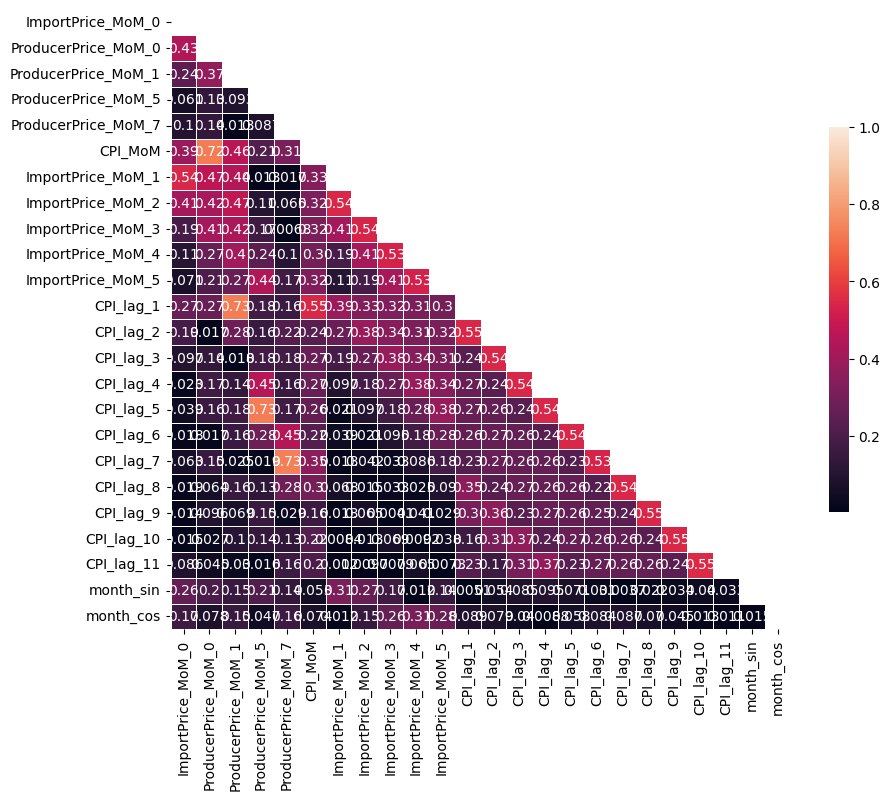

In [1441]:
import matplotlib.pyplot as plt
import seaborn as sns
corr=np.abs(target_features.corr())
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(10, 10))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)
plt.show()

In [1442]:
#Let's try Random Forest

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

X = features
y = target

tscv = TimeSeriesSplit(n_splits=3)

scores = []

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    forest = RandomForestRegressor(
        n_estimators=15,
        max_depth=3,
        random_state=40
    )

    forest.fit(X_train, y_train)

    pred = forest.predict(X_test)

    scores.append(forest.score(X_test, y_test))

print("Scores:", scores)
print("Mean R²:", sum(scores)/len(scores))


Scores: [0.20105193007852606, -0.1401627481178478, -0.5741681040128344]
Mean R²: -0.17109297401738535


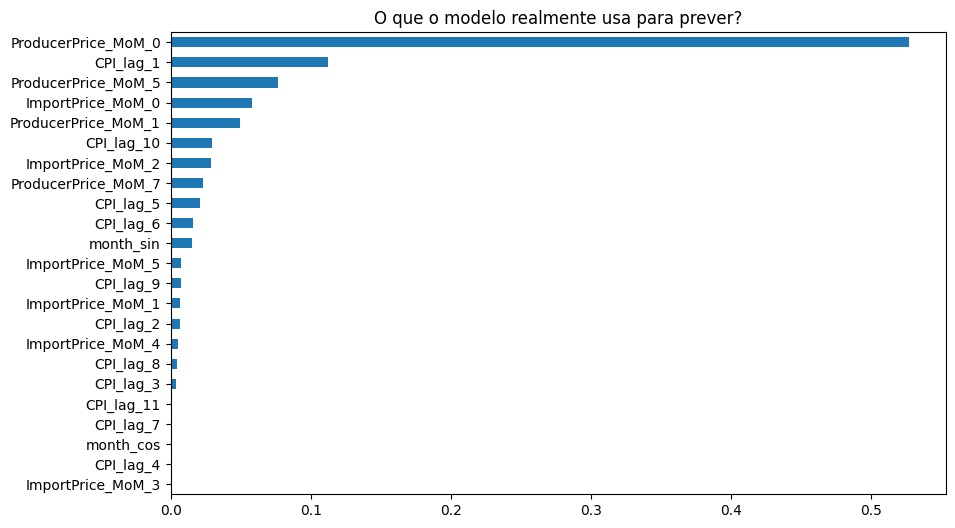

In [1443]:
importances = pd.Series(forest.feature_importances_, index=features.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("O que o modelo realmente usa para prever?")
plt.show()

In [1444]:
#Lets try gradientboost
from sklearn.ensemble import GradientBoostingRegressor

X = features
y = target

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = GradientBoostingRegressor(
        n_estimators=15,
        learning_rate=0.05,
        max_depth=3,
        random_state=40
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    scores.append(model.score(X_test, y_test))

print("Scores:", scores)
print("Mean R²:", sum(scores)/len(scores))

Scores: [0.2992836111016226, 0.180393832794021, -0.30041177688290177, 0.47158868602008985, -0.46649293050803897]
Mean R²: 0.03687228450495854


In [1445]:
#Lets try xgbRegressor
from xgboost import XGBRegressor

X = features
y = target

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=15,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=40
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    scores.append(model.score(X_test, y_test))

print("Scores:", scores)
print("Mean R²:", sum(scores)/len(scores))

Scores: [0.1991284267109915, 0.11540149125609922, -0.46241198988195964, 0.5371991440928492, -0.15953498790104992]
Mean R²: 0.045956416855386074


In [1446]:
#Let's try GridSearch: Random Forest
from sklearn.model_selection import GridSearchCV

X = features
y = target

tscv = TimeSeriesSplit(n_splits=3)

forest = RandomForestRegressor(random_state=40)

param_grid = {
    "n_estimators": [10, 15, 35, 50, 100, 150, 200, 250],
    "max_depth": [1, 2, 3, 5, None],
    "min_samples_leaf": [1, 2, 4, 5, 6, 7]
}

grid = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)


Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 10}
Best R²: -0.08453029749293235


In [1447]:
#Let's try GridSearch: gradientboost


X = features
y = target

tscv = TimeSeriesSplit(n_splits=3)

model = GradientBoostingRegressor()

param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_leaf': 2, 'n_estimators': 300}
Best R²: -0.020700044449931492


In [1448]:
#Let's try GridSearch: gradientboost


X = features
y = target

tscv = TimeSeriesSplit(n_splits=3)

# modelo base
model = XGBRegressor(
    random_state=40,
    objective="reg:squarederror"
)


# parâmetros a testar
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3],
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best R²:", grid.best_score_)

Best parameters: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100}
Best R²: -0.18326670883687798


In [1449]:
#Let's try ElasticNet

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = features
y = target

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("elastic", ElasticNet(
            alpha=0.1,
            l1_ratio=0.5,
            random_state=40
        ))
    ])

    model.fit(X_train, y_train)

    scores.append(model.score(X_test, y_test))

print("Scores:", scores)
print("Mean R²:", sum(scores)/len(scores))

Scores: [0.5578569673086635, 0.3661138915086458, 0.2404990202527546, 0.5474252228421921, -0.2956069665544381]
Mean R²: 0.2832576270715636


In [1450]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = features
y = target

tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(random_state=0))
])

param_grid = {
    "elastic__alpha": [0.0001,0.001,0.01,0.1,0.125,0.15,0.175,0.20,0.25,0.275,0.3,0.325,0.35,0.375,0.4,0.425,0.45,0.475,0.50,0.55,0.60,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1],
    "elastic__l1_ratio": [0.005,0.0075,0.01,0.015,0.020,0.025,0.03,0.035,0.04,0.045,0.05,0.06,0.07,0.08,0.09,0.1,0.15,0.20,0.25,0.5,0.75,0.9]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)

print("Best parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)



Best parameters: {'elastic__alpha': 0.5, 'elastic__l1_ratio': 0.01}
Best CV R²: 0.4024130369698732


In [1451]:
best_model = grid.best_estimator_

pred = best_model.predict(X)

print("Model ready")

Model ready


In [1452]:
import pandas as pd

coef = best_model.named_steps["elastic"].coef_

importance = pd.Series(coef, index=features.columns)

print(importance.sort_values(ascending=False))

ProducerPrice_MoM_0    0.100639
CPI_lag_1              0.036278
ProducerPrice_MoM_1    0.029351
ImportPrice_MoM_0      0.025054
CPI_lag_7              0.021463
month_cos              0.019199
CPI_lag_10             0.017932
ImportPrice_MoM_5      0.017733
CPI_lag_8              0.016886
CPI_lag_11             0.014350
ProducerPrice_MoM_7    0.013654
CPI_lag_3              0.006086
ImportPrice_MoM_4      0.005821
ProducerPrice_MoM_5    0.005681
ImportPrice_MoM_2      0.004905
CPI_lag_9              0.002299
CPI_lag_5              0.001659
CPI_lag_6              0.001612
ImportPrice_MoM_3      0.001426
CPI_lag_4              0.000069
ImportPrice_MoM_1      0.000000
CPI_lag_2             -0.001313
month_sin             -0.023408
dtype: float64


In [1453]:
#I need to extend original series up to dec 2027
target_features_originals = target_features[["ImportPrice_MoM_0","ProducerPrice_MoM_0","CPI_MoM","month_sin","month_cos"]]
target_features_originals

,ImportPrice_MoM_0,ProducerPrice_MoM_0,CPI_MoM,month_sin,month_cos
observation_date,,,,,
2016-09-01,-0.101730,0.27397,0.26232,-1.000000e+00,-1.836970e-16
2016-10-01,0.000000,0.38251,0.23427,-8.660254e-01,5.000000e-01
2016-11-01,-0.101830,-0.27218,0.11789,-5.000000e-01,8.660254e-01
2016-12-01,0.000000,0.38210,0.25245,-2.449294e-16,1.000000e+00
2017-01-01,0.101940,0.92442,0.40431,5.000000e-01,8.660254e-01
...,...,...,...,...,...
2025-08-01,0.182480,0.01932,0.34826,-8.660254e-01,-5.000000e-01
2025-09-01,0.000000,0.36658,0.29509,-1.000000e+00,-1.836970e-16
2025-10-01,0.090663,-0.47875,0.29599,-8.660254e-01,5.000000e-01


In [1454]:
future_dates = pd.date_range(
    df.index[-1],
    periods=25,
    freq="MS"
)[1:]

future_month = future_dates.month

month_sin = np.sin(2*np.pi*future_month/12)
month_cos = np.cos(2*np.pi*future_month/12)


In [1455]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    target_features_originals["ImportPrice_MoM_0"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)  # sazonalidade anual
)

fit = model.fit()

forecast_import = fit.forecast(24)

c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [1456]:
forecast_import.tail(30)

2026-01-01    0.239045
2026-02-01    0.183420
2026-03-01    0.134658
2026-04-01    0.104216
2026-05-01    0.064646
2026-06-01    0.016428
2026-07-01    0.010224
2026-08-01    0.021479
2026-09-01    0.021496
2026-10-01    0.028279
2026-11-01    0.003479
2026-12-01    0.044115
2027-01-01    0.104183
2027-02-01    0.084334
2027-03-01    0.061877
2027-04-01    0.050739
2027-05-01    0.025408
2027-06-01   -0.012282
2027-07-01   -0.010858
2027-08-01    0.005945
2027-09-01    0.010065
2027-10-01    0.019838
2027-11-01   -0.002659
2027-12-01    0.039458
Freq: MS, Name: predicted_mean, dtype: float64

In [1457]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    target_features_originals["ProducerPrice_MoM_0"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)  # sazonalidade anual
)

fit = model.fit()

forecast_producer = fit.forecast(24)
forecast_producer

c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01   -0.284296
2026-02-01   -0.146298
2026-03-01   -0.143282
2026-04-01   -0.019096
2026-05-01    0.093996
2026-06-01    0.055302
2026-07-01    0.082785
2026-08-01    0.105501
2026-09-01    0.167677
2026-10-01   -0.155745
2026-11-01    0.075862
2026-12-01   -0.191393
2027-01-01   -0.131956
2027-02-01   -0.023335
2027-03-01    0.012387
2027-04-01   -0.000218
2027-05-01   -0.017990
2027-06-01   -0.010269
2027-07-01   -0.015040
2027-08-01   -0.019094
2027-09-01   -0.030320
2027-10-01    0.028156
2027-11-01   -0.013716
2027-12-01    0.034602
Freq: MS, Name: predicted_mean, dtype: float64

In [1458]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(target_features_originals["CPI_MoM"], order=(1,0,1))
fit = model.fit()

forecast_cpi = fit.forecast(24)
forecast_cpi

c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\rcrds\anaconda3\envs\MyEnvironment\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    0.292904
2026-02-01    0.277261
2026-03-01    0.275503
2026-04-01    0.275305
2026-05-01    0.275283
2026-06-01    0.275281
2026-07-01    0.275280
2026-08-01    0.275280
2026-09-01    0.275280
2026-10-01    0.275280
2026-11-01    0.275280
2026-12-01    0.275280
2027-01-01    0.275280
2027-02-01    0.275280
2027-03-01    0.275280
2027-04-01    0.275280
2027-05-01    0.275280
2027-06-01    0.275280
2027-07-01    0.275280
2027-08-01    0.275280
2027-09-01    0.275280
2027-10-01    0.275280
2027-11-01    0.275280
2027-12-01    0.275280
Freq: MS, Name: predicted_mean, dtype: float64

In [1459]:
estimate_test = pd.DataFrame()
estimate_test["ImportPrice_MoM_0"] = forecast_import
estimate_test["ProducerPrice_MoM_0"] = forecast_producer
estimate_test["month_sin"] = month_sin
estimate_test["month_cos"] = month_cos
estimate_test["CPI_MoM"] = forecast_cpi
estimate_test.tail()

,ImportPrice_MoM_0,ProducerPrice_MoM_0,month_sin,month_cos,CPI_MoM
2027-08-01,0.005945,-0.019094,-8.660254e-01,-5.000000e-01,0.27528
2027-09-01,0.010065,-0.030320,-1.000000e+00,-1.836970e-16,0.27528
2027-10-01,0.019838,0.028156,-8.660254e-01,5.000000e-01,0.27528
2027-11-01,-0.002659,-0.013716,-5.000000e-01,8.660254e-01,0.27528
2027-12-01,0.039458,0.034602,-2.449294e-16,1.000000e+00,0.27528


In [1460]:
target_features_originals.head()

,ImportPrice_MoM_0,ProducerPrice_MoM_0,CPI_MoM,month_sin,month_cos
observation_date,,,,,
2016-09-01,-0.10173,0.27397,0.26232,-1.000000e+00,-1.836970e-16
2016-10-01,0.00000,0.38251,0.23427,-8.660254e-01,5.000000e-01
2016-11-01,-0.10183,-0.27218,0.11789,-5.000000e-01,8.660254e-01
2016-12-01,0.00000,0.38210,0.25245,-2.449294e-16,1.000000e+00
2017-01-01,0.10194,0.92442,0.40431,5.000000e-01,8.660254e-01


In [1461]:
full_table = pd.concat([target_features_originals,estimate_test])
full_table

,ImportPrice_MoM_0,ProducerPrice_MoM_0,CPI_MoM,month_sin,month_cos
2016-09-01,-0.101730,0.273970,0.26232,-1.000000e+00,-1.836970e-16
2016-10-01,0.000000,0.382510,0.23427,-8.660254e-01,5.000000e-01
2016-11-01,-0.101830,-0.272180,0.11789,-5.000000e-01,8.660254e-01
2016-12-01,0.000000,0.382100,0.25245,-2.449294e-16,1.000000e+00
2017-01-01,0.101940,0.924420,0.40431,5.000000e-01,8.660254e-01
...,...,...,...,...,...
2027-08-01,0.005945,-0.019094,0.27528,-8.660254e-01,-5.000000e-01
2027-09-01,0.010065,-0.030320,0.27528,-1.000000e+00,-1.836970e-16
2027-10-01,0.019838,0.028156,0.27528,-8.660254e-01,5.000000e-01
2027-11-01,-0.002659,-0.013716,0.27528,-5.000000e-01,8.660254e-01


In [1462]:

for i in range(1,6):
    full_table[f"ImportPrice_MoM_{i}"] = full_table["ImportPrice_MoM_0"].shift(i)
full_table["ProducerPrice_MoM_1"] = full_table["ProducerPrice_MoM_0"].shift(1)
full_table["ProducerPrice_MoM_5"] = full_table["ProducerPrice_MoM_0"].shift(5)
full_table["ProducerPrice_MoM_7"] = full_table["ProducerPrice_MoM_0"].shift(7)

for i in range(1,12):
    full_table[f"CPI_MoM_{i}"] = full_table["CPI_MoM"].shift(i)

full_table.dropna(inplace=True)
full_table

,ImportPrice_MoM_0,ProducerPrice_MoM_0,CPI_MoM,month_sin,month_cos,ImportPrice_MoM_1,ImportPrice_MoM_2,ImportPrice_MoM_3,ImportPrice_MoM_4,ImportPrice_MoM_5,...,CPI_MoM_2,CPI_MoM_3,CPI_MoM_4,CPI_MoM_5,CPI_MoM_6,CPI_MoM_7,CPI_MoM_8,CPI_MoM_9,CPI_MoM_10,CPI_MoM_11
2017-08-01,0.202220,0.587290,0.38486,-8.660254e-01,-5.000000e-01,0.000000,0.000000,0.000000,0.202630,0.203050,...,0.06516,-0.07740,0.12342,-0.04672,0.15927,0.40431,0.25245,0.11789,0.23427,0.26232
2017-09-01,0.201820,0.636940,0.51064,-1.000000e+00,-1.836970e-16,0.202220,0.000000,0.000000,0.000000,0.202630,...,0.03276,0.06516,-0.07740,0.12342,-0.04672,0.15927,0.40431,0.25245,0.11789,0.23427
2017-10-01,0.201410,0.316460,0.07751,-8.660254e-01,5.000000e-01,0.201820,0.202220,0.000000,0.000000,0.000000,...,0.38486,0.03276,0.06516,-0.07740,0.12342,-0.04672,0.15927,0.40431,0.25245,0.11789
2017-11-01,0.100500,0.525760,0.26680,-5.000000e-01,8.660254e-01,0.201410,0.201820,0.202220,0.000000,0.000000,...,0.51064,0.38486,0.03276,0.06516,-0.07740,0.12342,-0.04672,0.15927,0.40431,0.25245
2017-12-01,-0.100400,0.052300,0.21069,-2.449294e-16,1.000000e+00,0.100500,0.201410,0.201820,0.202220,0.000000,...,0.07751,0.51064,0.38486,0.03276,0.06516,-0.07740,0.12342,-0.04672,0.15927,0.40431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2027-08-01,0.005945,-0.019094,0.27528,-8.660254e-01,-5.000000e-01,-0.010858,-0.012282,0.025408,0.050739,0.061877,...,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528
2027-09-01,0.010065,-0.030320,0.27528,-1.000000e+00,-1.836970e-16,0.005945,-0.010858,-0.012282,0.025408,0.050739,...,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528
2027-10-01,0.019838,0.028156,0.27528,-8.660254e-01,5.000000e-01,0.010065,0.005945,-0.010858,-0.012282,0.025408,...,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528
2027-11-01,-0.002659,-0.013716,0.27528,-5.000000e-01,8.660254e-01,0.019838,0.010065,0.005945,-0.010858,-0.012282,...,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528,0.27528


In [1463]:
features = full_table.drop(columns="CPI_MoM")
target = full_table["CPI_MoM"]

split_date = "2026-01-01"
X_train = features[features.index < split_date]
X_test = features[features.index >= split_date]

y_train = target[target.index < split_date]
y_test = target[target.index >= split_date]

In [1464]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(random_state=0))
])

param_grid = {
    "elastic__alpha": [0.0001,0.001,0.01,0.1,0.125,0.15,0.175,0.2,0.25,0.275,0.3,0.325,0.35,0.375,0.4,0.425,0.45,0.475,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,1],
    "elastic__l1_ratio": [0.005,0.0075,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.06,0.07,0.08,0.09,0.1,0.15,0.2,0.25,0.5,0.75,0.9]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,      
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best parameters: {'elastic__alpha': 0.15, 'elastic__l1_ratio': 0.05}
Best CV R²: 0.39448261961900694


In [1465]:
y_pred = grid.best_estimator_.predict(X_test)
y_pred

array([0.16202468, 0.16329352, 0.15600734, 0.17612584, 0.19690601,
       0.22100553, 0.24173761, 0.27039835, 0.29826281, 0.26798399,
       0.27911542, 0.23823333, 0.2156674 , 0.20319366, 0.18713852,
       0.17546271, 0.1739153 , 0.19359518, 0.21589879, 0.2423547 ,
       0.26254918, 0.27915405, 0.26847825, 0.25949289])

In [1466]:
target_features_originals = target_features_originals.rename(columns={"ImportPrice_MoM_0":"ImportPrice_real","ProducerPrice_MoM_0":"ProducerPrice_real", "CPI_MoM":"CPI_real"})
target_features_originals = target_features_originals.drop(columns=["month_sin","month_cos"])
target_features_originals

,ImportPrice_real,ProducerPrice_real,CPI_real
observation_date,,,
2016-09-01,-0.101730,0.27397,0.26232
2016-10-01,0.000000,0.38251,0.23427
2016-11-01,-0.101830,-0.27218,0.11789
2016-12-01,0.000000,0.38210,0.25245
2017-01-01,0.101940,0.92442,0.40431
...,...,...,...
2025-08-01,0.182480,0.01932,0.34826
2025-09-01,0.000000,0.36658,0.29509
2025-10-01,0.090663,-0.47875,0.29599


In [1467]:
estimate_test["CPI_MoM"] = y_pred
estimate_test = estimate_test.rename(index={"":"observation_date"},columns={"ImportPrice_MoM_0":"ImportPrice_est","ProducerPrice_MoM_0":"ProducerPrice_est","CPI_MoM":"CPI_est"})
estimate_test = estimate_test.drop(columns=["month_sin","month_cos"])
estimate_test

,ImportPrice_est,ProducerPrice_est,CPI_est
2026-01-01,0.239045,-0.284296,0.162025
2026-02-01,0.183420,-0.146298,0.163294
2026-03-01,0.134658,-0.143282,0.156007
2026-04-01,0.104216,-0.019096,0.176126
2026-05-01,0.064646,0.093996,0.196906
2026-06-01,0.016428,0.055302,0.221006
2026-07-01,0.010224,0.082785,0.241738
2026-08-01,0.021479,0.105501,0.270398
2026-09-01,0.021496,0.167677,0.298263
2026-10-01,0.028279,-0.155745,0.267984


In [1468]:
real_est=pd.concat([target_features_originals,estimate_test],axis=1)
real_est

,ImportPrice_real,ProducerPrice_real,CPI_real,ImportPrice_est,ProducerPrice_est,CPI_est
2016-09-01,-0.10173,0.27397,0.26232,NaN,NaN,NaN
2016-10-01,0.00000,0.38251,0.23427,NaN,NaN,NaN
2016-11-01,-0.10183,-0.27218,0.11789,NaN,NaN,NaN
2016-12-01,0.00000,0.38210,0.25245,NaN,NaN,NaN
2017-01-01,0.10194,0.92442,0.40431,NaN,NaN,NaN
...,...,...,...,...,...,...
2027-08-01,NaN,NaN,NaN,0.005945,-0.019094,0.242355
2027-09-01,NaN,NaN,NaN,0.010065,-0.030320,0.262549
2027-10-01,NaN,NaN,NaN,0.019838,0.028156,0.279154
2027-11-01,NaN,NaN,NaN,-0.002659,-0.013716,0.268478


In [1469]:
real_est.to_csv(r"C:\Users\rcrds\Desktop\Ironhack\Final Project\Clean Datasets\real_est.csv")
